In [1]:
# Runtime evidence: this cell checks the environment actually used by the kernel.
import sys as _shape_sys, json as _shape_json, importlib.util as _shape_util
print("SHAPE_RUNTIME_PROVENANCE=" + _shape_json.dumps({
    "python_executable": _shape_sys.executable,
    "python_version": _shape_sys.version.split()[0],
    "shape_lab_origin": _shape_util.find_spec("shape_lab").origin
}))
del _shape_sys, _shape_json, _shape_util


SHAPE_RUNTIME_PROVENANCE={"python_executable": "/opt/pyvenv/bin/python", "python_version": "3.13.5", "shape_lab_origin": "/tmp/shape-course-q90rdcpz/course/src/shape_lab/__init__.py"}


# Stage 23 — Mechanics, Hamiltonian networks and Lagrangian networks

Manufactured oscillator derivative data for training; observed copper data used to examine what is and is not identifiable.

This is an executed reference, not a learner assessment. Read the lesson and predict the results before running. All code is inspectable in `src/shape_lab/physics`. No model or dataset downloads occur.

In [2]:
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib','inline')
STAGE=23
from pathlib import Path
import sys, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT=Path.cwd()
while not (ROOT/'pyproject.toml').exists() and ROOT.parent!=ROOT:ROOT=ROOT.parent
if not (ROOT/'pyproject.toml').exists():raise RuntimeError('Open this notebook within the extracted project.')
sys.path.insert(0,str(ROOT/'src'))
from shape_lab.physics import classical as c, constraints as con, gradients as grad, operators as op
hahn=pd.read_csv(ROOT/'data/physics/hahn1_excerpt.csv')
hahn_manifest=json.loads((ROOT/'data/physics/manifest.json').read_text())
OUT=ROOT/'physics/reports'/f'{STAGE:02d}'
OUT.mkdir(parents=True,exist_ok=True)
def save_report(result):
    result={'stage':STAGE,'role':'executed teaching experiment; not learner assessment',**result}
    result['source_review_date']='2026-09-20'
    (OUT/'results.json').write_text(json.dumps(result,indent=2,allow_nan=False)+'\n')
    print(json.dumps(result,indent=2))
def finish_figure(name):
    plt.tight_layout();plt.savefig(OUT/f'{name}.png',dpi=140,bbox_inches='tight');plt.show();plt.close()
print('Course:', ROOT.name, '| stage:', STAGE)


Course: course | stage: 23


## Derive before training
L=v²−1.5q² gives acceleration −3 at q=2. The general scalar formula and the restricted trained L model are different examples.

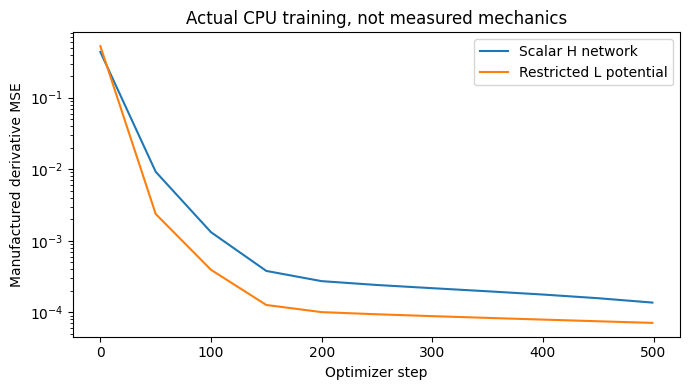

In [3]:
import torch
from shape_lab.physics.neural import lagrangian_acceleration,train_mechanics
acc=lagrangian_acceleration(lambda z:z[1]**2-1.5*z[0]**2,torch.tensor([2.,.4],dtype=torch.float64))
assert abs(float(acc.detach())+3)<1e-12
result=train_mechanics(steps=500,seed=5)
np.savez(OUT/'derivative_predictions.npz',test=result['test'],hnn=result['hnn_prediction'],lnn=result['lnn_acceleration'])
h=np.array(result['history'])
plt.figure(figsize=(7,4));plt.semilogy(h[:,0],h[:,1],label='Scalar H network');plt.semilogy(h[:,0],h[:,2],label='Restricted L potential');plt.xlabel('Optimizer step');plt.ylabel('Manufactured derivative MSE');plt.legend();plt.title('Actual CPU training, not measured mechanics');finish_figure('training')

## Is the real material dataset suitable for this task?
Inspect its actual fields. Reject the proposed dynamics interpretation rather than silently synthesizing missing momentum labels.

In [4]:
required_fields={'time_s','position_m','canonical_momentum'}
missing=sorted(required_fields-set(hahn.columns))
assert missing
print('Observed copper fields:',list(hahn.columns),'| missing for the proposed HNN trajectory:',missing)
metrics=result['metrics'];metrics['observed_data_admissibility']={'dataset':'NIST Hahn1 excerpt','rows':len(hahn),'missing_trajectory_fields':missing,'decision':'Not suitable as measured trajectory training data; static regression remains valid.'}
metrics['hand_acceleration']=float(acc.detach());save_report(metrics)

Observed copper fields: ['source_observation', 'temperature_K', 'expansion_response'] | missing for the proposed HNN trajectory: ['canonical_momentum', 'position_m', 'time_s']
{
  "stage": 23,
  "role": "executed teaching experiment; not learner assessment",
  "data_kind": "manufactured unit oscillator derivative samples",
  "seed": 5,
  "steps": 500,
  "train_states": 256,
  "test_states": 128,
  "hnn_test_derivative_mse": 0.00018408787499218164,
  "restricted_lnn_test_acceleration_mse": 8.365068142685891e-05,
  "scope": "No measured trajectories; no canonical-coordinate learning; no general-LNN Hessian training.",
  "observed_data_admissibility": {
    "dataset": "NIST Hahn1 excerpt",
    "rows": 56,
    "missing_trajectory_fields": [
      "canonical_momentum",
      "position_m",
      "time_s"
    ],
    "decision": "Not suitable as measured trajectory training data; static regression remains valid."
  },
  "hand_acceleration": -3.0,
  "source_review_date": "2026-09-20"
}


## Independent explanation

Write the data origin, one supported conclusion and one unsupported conclusion. Change one parameter while preserving the comparison horizon or unit. Save your answer separately; successful reference execution is not proof that you understand the result.